In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('data/transfers.csv')
df.head()

,from,to,amount,timestamp
0,acct_0542,acct_0739,0.000001,2025-12-17 01:29:56.977+03
1,acct_0066,acct_0623,0.000001,2025-12-17 01:33:08.573+03
2,acct_0066,acct_0469,0.000001,2025-12-17 01:33:08.573+03
3,acct_0140,acct_0148,0.000001,2025-12-17 01:43:36.145+03
4,acct_0140,acct_0675,0.000001,2025-12-17 01:43:36.145+03


# EDA

## Общая структура и качество

In [2]:
print(df.shape)
print(df.dtypes)

(5863, 4)
from             str
to               str
amount       float64
timestamp        str
dtype: object


In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')
print(df.dtypes)

from                               str
to                                 str
amount                         float64
timestamp    datetime64[us, UTC+03:00]
dtype: object


In [4]:
print(df.isna().sum())

from         0
to           0
amount       0
timestamp    0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 40


In [6]:
print("Self-transfers:", (df['from']==df['to']).sum())

Self-transfers: 0


## Распределение сумм

In [7]:
print(df["amount"].describe())
print(df["amount"].value_counts().sort_index())

count    5863.000000
mean        0.000009
std         0.000024
min         0.000001
25%         0.000001
50%         0.000001
75%         0.000001
max         0.000100
Name: amount, dtype: float64
amount
0.000001    5220
0.000010      29
0.000020      58
0.000030      51
0.000040      60
0.000050      52
0.000060      31
0.000070      26
0.000080      26
0.000090      10
0.000100     300
Name: count, dtype: int64


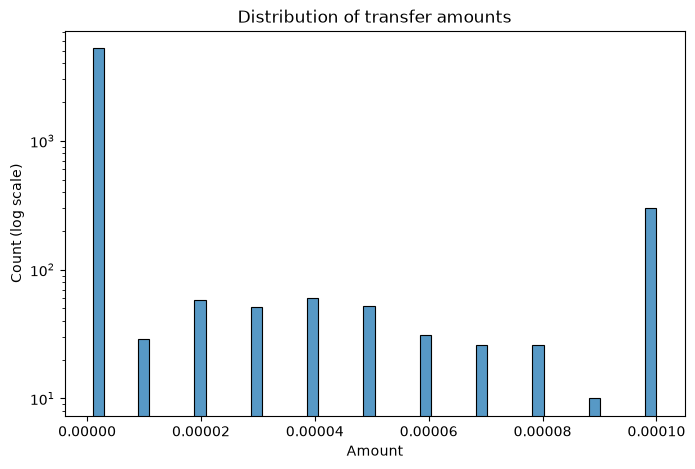

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["amount"], bins=50, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Amount")
ax.set_ylabel("Count (log scale)")
ax.set_title("Distribution of transfer amounts")
plt.show()

89% транзакций (5220 из 5863) — это минимальная сумма 0.000001, скорее всего просто dust
(мелкий технический шум, типа маркировки адресов или сканирования сети, а не реальные переводы)
Остальное - 11 четких уровней сумм от 0.000001 до 0.0001, причем на 0.0001 отдельный
пик (300 штук) - похоже на что-то осмысленное
Короче делю на два слоя: отдельно смотрю dust (кто его рассылает/собирает — может это
паттерн раздачи) и отдельно real-value (тут уже ищу циклы, hub-аккаунты, группы)

## Временной диапазон

range: 2025-12-17 01:29:56.977000+03:00 -> 2026-06-29 11:09:42.252000+03:00
span (days): 194


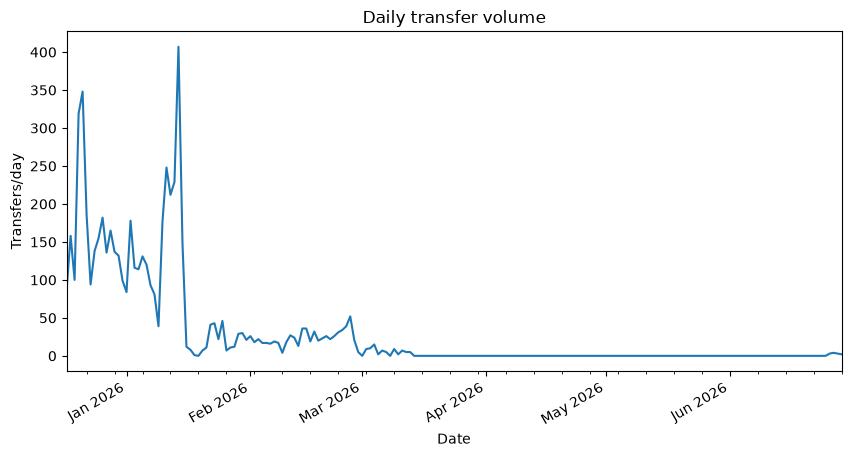

In [9]:
import matplotlib.dates as mdates

print("range:", df["timestamp"].min(), "->", df["timestamp"].max())
print("span (days):", (df["timestamp"].max() - df["timestamp"].min()).days)

daily = df.set_index("timestamp").resample("D").size()

fig, ax = plt.subplots(figsize=(10, 5))
daily.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

ax.set_xlabel("Date")
ax.set_ylabel("Transfers/day")
ax.set_title("Daily transfer volume")
plt.show()

In [10]:
print(daily["2026-01-10":"2026-01-25"])

timestamp
2026-01-10 00:00:00+03:00    177
2026-01-11 00:00:00+03:00    248
2026-01-12 00:00:00+03:00    212
2026-01-13 00:00:00+03:00    229
2026-01-14 00:00:00+03:00    407
2026-01-15 00:00:00+03:00    149
2026-01-16 00:00:00+03:00     12
2026-01-17 00:00:00+03:00      8
2026-01-18 00:00:00+03:00      1
2026-01-19 00:00:00+03:00      0
2026-01-20 00:00:00+03:00      7
2026-01-21 00:00:00+03:00     11
2026-01-22 00:00:00+03:00     41
2026-01-23 00:00:00+03:00     43
2026-01-24 00:00:00+03:00     22
2026-01-25 00:00:00+03:00     46
Freq: D, dtype: int64


Данные охватывают 17 дек 2025 - 29 июня 2026 (194 дня), активность сильно скачет. Пик - 407 переводов 14 января, а дальше резко ложится 15-19 января (149-12-8-1-0), явно не само по себе затухло. После 20 января сеть не умирает, а держится на пониженном уровне (10-45/день) до конца февраля, и только с марта по июнь реально уходит в ноль. Получается два перелома - сначала резкий обвал ~15 января, потом окончательное затухание в начале марта, и это подозрительно само по себе. Надо зафиксировать обе даты и проверить, не пропадают ли именно после 15 января конкретные аккаунты из активности.


## Аккаунты: sender-only / receiver-only

In [11]:
all_accts = set(df["from"]) | set(df["to"])
sender_only = set(df["from"]) - set(df["to"])
receiver_only = set(df["to"]) - set(df["from"])

print("unique accounts:", len(all_accts))
print("sender-only:", len(sender_only), sorted(sender_only))
print("receiver-only:", len(receiver_only), sorted(receiver_only))


unique accounts: 1000
sender-only: 4 ['acct_0331', 'acct_0446', 'acct_0676', 'acct_0746']
receiver-only: 10 ['acct_0383', 'acct_0403', 'acct_0476', 'acct_0504', 'acct_0544', 'acct_0669', 'acct_0718', 'acct_0732', 'acct_0745', 'acct_0880']


Из 1000 уникальных аккаунтов 4 только отправляют деньги и никогда не получают (похоже на источники или эмиссию). 10 аккаунтов, наоборот, только получают и никогда не отправляют (кандидаты на точки консолидации или кэшаут).

## Одновременные переводы с одного аккаунта

1    5175
2     108
3      62
4      31
5      20
6       8
7       2
Name: count, dtype: int64


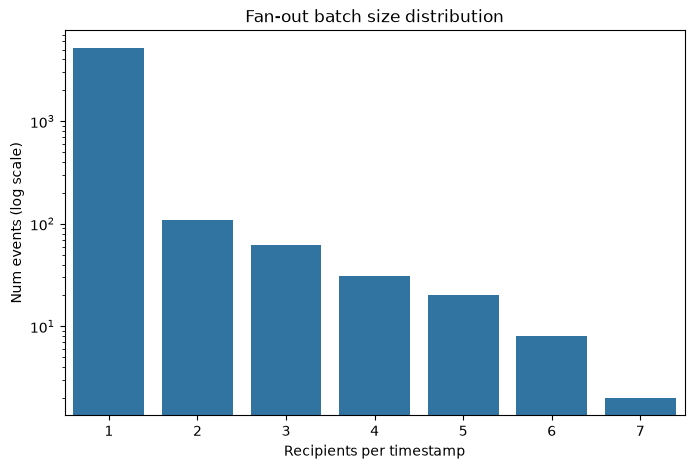

In [12]:
batch = df.groupby(["from", "timestamp"]).size()
batch_dist = batch.value_counts().sort_index()
print(batch_dist)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=batch_dist.index, y=batch_dist.values, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Recipients per timestamp")
ax.set_ylabel("Num events (log scale)")
ax.set_title("Fan-out batch size distribution")
plt.show()

In [13]:
big_batches = batch[batch >= 4]
print(big_batches)

from       timestamp                       
acct_0331  2026-01-10 21:51:58.422000+03:00    7
           2026-01-10 22:24:33.587000+03:00    5
           2026-01-13 01:46:33.029000+03:00    4
           2026-01-13 13:31:26.510000+03:00    4
           2026-01-13 13:32:02.233000+03:00    4
                                              ..
           2026-01-15 00:05:29.636000+03:00    6
           2026-01-15 00:06:04.995000+03:00    5
           2026-01-15 00:06:37.508000+03:00    4
           2026-01-15 00:08:55.750000+03:00    6
acct_0750  2025-12-17 04:21:28.487000+03:00    5
Length: 61, dtype: int64


61 крупный batch (4+ получателей), почти все от acct_0331, все в окне 10-15 января. Мб скриптовая раздача с одного источника. Основа гипотезы "один владелец = несколько субкошельков"

## Выводы для основного анализа

1. Дедуплицировать 40 точных дублей строк перед построением графа.
2. Разделить транзакции на dust (amount == 0.000001) и real-value слои, затем анализировать паттерны отдельно, иначе шум маскирует сигнал.
3. Batch fan-out — 231 событие, где один аккаунт платит 2+ получателям одним и тем же timestamp (суммарно 688 транзакций вовлечено). Основной сигнал для группировки владельцев.
4. Sender-only / receiver-only аккаунты — кандидаты на источники и точки консолидации, проверить их в fan-in/fan-out анализе.

# Построение графа

Наш граф будет направленный (DiGraph), тк направление перевода приницпиально для поиска циклов и ролей отправителя/получателя.

Повторные переводы между одной парой аккаунтов схлопываю в одно ребро (суммарный вес + счётчик). Для структурных алгоритмов (циклы, degree) не важно, было между A и B 5 переводов или 1 — важен сам факт связи. Если оставить мультиграф, поиск циклов будет и медленнее, и найдёт один и тот же цикл по 5 раз.

Перед этим убираю 40 дублей строк, которые нашёл в EDA — иначе count по рёбрам будет врать.

Строю два графа: G_full (со всем dustом) и G_real (только нормальные суммы). Dust при этом не выкидываю совсем, в G_full связь видна в любом случае, даже если аккаунты общались только мелкими суммами, а это тоже может быть паттерном (типа structuring под порог). Сам dust отдельно буду смотреть через частоту/velocity, а не через вес графа.

Еще моментик: граф хранит только структуру связей, но не время каждого перевода. Поэтому pass-through, dust-спам и обвал активности 15 января я буду разбирать напрямую по df, а не через граф.

In [14]:
from analyze import load_transfers, split_dust_real, build_graph

df = load_transfers("data/transfers.csv")
dust_df, real_df = split_dust_real(df)

G_full = build_graph(df)
G_real = build_graph(real_df)

print(f"Full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")
print(f"Real-value graph: {G_real.number_of_nodes()} nodes, {G_real.number_of_edges()} edges")

убрал 40 дублей
dust: 5180, real: 643
Full graph: 1000 nodes, 5513 edges
Real-value graph: 627 nodes, 643 edges


In [17]:
import networkx as nx
import plotly.graph_objects as go

pos = nx.spring_layout(G_real, seed=42, k=0.3)

edge_x, edge_y = [], []
for u, v in G_real.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=0.5, color="gray"), mode="lines")

node_x = [pos[n][0] for n in G_real.nodes()]
node_y = [pos[n][1] for n in G_real.nodes()]
node_text = list(G_real.nodes())
degrees = [G_real.degree(n) for n in G_real.nodes()]

node_trace = go.Scatter(
    x=node_x, y=node_y, mode="markers", text=node_text, hoverinfo="text",
    marker=dict(size=[5 + d * 2 for d in degrees], color=degrees, colorscale="Viridis", showscale=True)
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(title="Real-value transfer graph", showlegend=False)
fig.show()

In [20]:
degrees = dict(G_real.degree())
top10 = sorted(degrees.items(), key=lambda x: -x[1])[:10]
print(top10)

[('acct_0331', 613), ('acct_0746', 11), ('acct_0097', 3), ('acct_0743', 3), ('acct_0060', 2), ('acct_0764', 2), ('acct_0079', 2), ('acct_0648', 2), ('acct_0306', 2), ('acct_0332', 2)]


In [18]:
print("out-degree:", G_real.out_degree("acct_0746"))
print("in-degree:", G_real.in_degree("acct_0746"))
print("total volume out:", sum(d["weight"] for _, _, d in G_real.out_edges("acct_0746", data=True)))
print("total volume in:", sum(d["weight"] for _, _, d in G_real.in_edges("acct_0746", data=True)))

out-degree: 11
in-degree: 0
total volume out: 0.00031000000000000005
total volume in: 0


In [19]:
sender_only = ["acct_0331", "acct_0446", "acct_0676", "acct_0746"]

for acc in sender_only:
    in_G_real = acc in G_real.nodes
    out_deg = G_real.out_degree(acc) if in_G_real else "не в G_real"
    in_deg = G_real.in_degree(acc) if in_G_real else "не в G_real"
    print(f"{acc}: в G_real={in_G_real}, out={out_deg}, in={in_deg}")

acct_0331: в G_real=True, out=613, in=0
acct_0446: в G_real=False, out=не в G_real, in=не в G_real
acct_0676: в G_real=False, out=не в G_real, in=не в G_real
acct_0746: в G_real=True, out=11, in=0


In [22]:
print("acct_0331 position check:")
pos = nx.spring_layout(G_real, seed=42, k=0.3)
print(pos["acct_0331"])

acct_0331 position check:
[-0.00976691  0.00185798]
